<a href="https://colab.research.google.com/github/a-sideffect/SC2001proj/blob/main/SC2001_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC2001 Project 1: Integration of Merge Sort & Insertion Sort

## Executive Summary
* **Objective:** Optimize standard Merge Sort by integrating Insertion Sort for small sub-array sizes ($\le S$) to eliminate recursive call overhead.
* **Key Metrics:** Total key comparisons and execution time (CPU time).

## 1. Algorithm Design & Implementation

### 1.1 Standard Merge Sort vs. Hybrid Sort
* **Merge Sort:** Recursive divide-and-conquer strategy down to single-element base cases.
* **Hybrid Algorithm:** Intercepts recursive splitting when array size drops to or below threshold $S$, switching directly to Insertion Sort.

### 1.2 Implementation Details
* **Language:** Python
* **Optimization:** In-place sub-array indexing using `low`, `mid`, and `high` boundaries to prevent memory allocation overhead.
* **Tracking:** Explicit comparison counter incremented on every element evaluation.

## 2. Theoretical Analysis

### 2.1 Standard Merge Sort
* **Time Complexity:** $\Theta(n \log n)$ key comparisons in worst, average, and best cases.

### 2.2 Hybrid Merge-Insertion Sort
* **Small Sub-array Sorting (Insertion Sort):** Sorting $n/S$ sub-arrays of size $S$ takes $\mathcal{O}(S^2)$ per block $\rightarrow \mathcal{O}(n S)$ total.
* **Merging Phase:** Merging $n/S$ sub-arrays takes $\mathcal{O}(n \log(n/S))$ key comparisons.
* **Overall Complexity:**
  $$\mathcal{O}\left(n S + n \log\left(\frac{n}{S}\right)\right)$$

## 3. Empirical Results & Analysis

### 3.1 Task (c)(i): Fixed $S$, Varying Input Size $n$
* **Dataset Sizes ($n$):** $1,000$ to $10,000,000$ random integers.
* **Observation:** Empirical comparison count matches theoretical $\mathcal{O}(n \log n)$ growth closely as $n$ scales.

### 3.2 Task (c)(ii): Fixed Input Size $n$, Varying $S$
* **Tested Range of $S$:** $[2, 5, 10, 20, 30, 50, 100, 200]$
* **Observation:** Key comparisons increase gradually as $S$ grows because Insertion Sort performs more comparisons ($\mathcal{O}(S^2)$) than Merge Sort ($\mathcal{O}(S \log S)$) on small lists.

### 3.3 Task (c)(iii): Determining Optimal $S$
* **Key Finding:** While $S=1$ minimizes key comparisons, CPU time reaches a minimum around $S \in [10, 30]$ due to reduced function call stack overhead.

## 4. Performance Benchmark ($n = 10,000,000$)

| Metric | Standard Merge Sort | Hybrid Sort (Optimal $S$) |
| :--- | :--- | :--- |
| **Key Comparisons** | Recorded Value | Recorded Value |
| **CPU Execution Time (s)** | Recorded Value | Recorded Value |

## 5. Conclusion & Team Work Allocation

### 5.1 Key Takeaways
* Hybrid Merge-Insertion Sort significantly improves real-world performance by cutting down recursion overhead.
* The choice of $S$ represents a trade-off between minimizing key comparisons and minimizing system execution time.

### 5.2 Team Member Contributions
* **Member 1:** Algorithm implementation and comparison tracking framework.
* **Member 2:** Dataset generation, execution benchmarking, and data plotting.
* **Member 3:** Theoretical complexity analysis and presentation slide preparation.

Why create a hybrid sort?
- merge sort's weakness: merge sort is an O(n log n) algorithm, but when subarray sizes get small (e.g., length <= 10), creating temporary array copies (left and right) and managing deep recursive call stacks introduces heavy overhead
- insertion sort's strenght: insertion sort has O(n^2) worst-case time, but for very small inputs, it is extremely fast because it operates in-place with zero allocation overhead and minimal memroy cache misses
- the hybrid solution: merge sort handles the large scale by dividing down to subarrays of size S. once a subarray is of size <= S, insertion sort takes over to sort that chunk quickly in-place. finally, merge sort stitches those small sorted chunks back together

# SC2001 Project 1: Integration of Merge Sort & Insertion Sort
1. **Executive Summary**
  - **Objective:** optimize standard merge sort by integrating insertion sort for small subarray sizes (<=S) to eliminate recursive call overhead
  - **Core Problem:** merge sort guarantees O(n log n) time complexity, but recursively partitioning down to single elements (n=1) creates heavy recursive stack frame allocations and temporary array copying overhead
  - **The Hybrid Solution:** merge sort divides large datasets efficiently down to a threshold size S. Once a subarray size drops to <= S, insertion sort sorts the block in-place with zero memory allocation overhead

# (a) Code Architecture & algorithm implementation
  - **Design Choices for Efficiency & Stability**
    1. **In-Place Index Bounds (low,mid,high):** Operating directly on array index bounds prevents allocating new python sublists during recursive splitting steps, saving memory
    2. **Shift-Based Insertion Sort:** Instead of performing repeated element swaps (3 memory assignments per swap), a shift-based approach picks up key = arr[i], shifts larger elements rights, and places key into its target index
    3. **Preserving Stability:** In merge(), using left[i] <= right[j] ensures equal elements from the left subarray are placed before equal elements from the right subarray, maintaining stable sort order

In [ ]:
def insertion_sort(arr, low, high):
  key_comparisons = 0
  #Loop through unsorted elements starting from the second element in the range
  for i in range(low + 1, high + 1):
    key = arr[i]    #Store current element in place
    j = i - 1       #Start comparing with element immediately to its left

  #Shift elements of arr[low...i-1] that are greater than key to one position ahead
    while j >= low:
      key_comparisons += 1   #Record comparison: arr[j] > key
      if arr[j] > key:
        arr[j + 1] = arr[j]   #Shift element right
        j -= 1
      else:
        break    #Found correct spot for key; stop shifting

    arr[j + 1] = key    #Place key into its sorted position

  return key_comparisons


def merge(arr, low, mid, high):
  #Slice target subarrays into temporary memory
  left = arr[low:mid + 1]
  right = arr[mid + 1:high + 1]

  i = 0    #Pointer for temporary 'left' array
  j = 0    #Pointer for temporary 'right' array
  k = low  #Pointer for main 'arr' where sorted elements are written back
  key_comparisons = 0

  #Compare elements from left and right, copying the smaller element back into arr
  while i < len(left) and j < len(right):
    key_comparisons += 1
    if left[i] <= right[j]:
      arr[k] = left[i]
      i += 1
    else:
      arr[k] = right[j]
      j += 1
    k += 1

  #Copy any leftover elements from 'left' (if any)
  while i < len(left):
    arr[k] = left[i]
    i += 1
    k += 1

  #Copy any leftover elements from 'right' (if any)
  while j < len(right):
    arr[k] = right[j]
    j += 1
    k += 1

  return key_comparisons


def hybrid_sort(arr, low, high, S):
  #Calculate current subarray length
  size = high - low + 1

  #Threshold Check: if subarray is small enough, switch to insertion sort
  if size <= S:
    return insertion_sort(arr, low, high)

  #Divide: calculate mid index without potential integer overflow
  mid = low + (high - low) // 2

  #Conquer: recursively divide left and right halves using hybrid_sort
  comps_left = hybrid_sort(arr, low, mid, S)
  comps_right = hybrid_sort(arr, mid+1, high, S)

  #Combine: merge the two sorted halves back together
  comps_merge = merge(arr, low, mid, high)

  #Return total comparison count up the call stack
  return comps_left + comps_right + comps_merge

# (b) Generate Input Data
  - **Generate arrays of increasing sizes**, in a range from 1000 to 10 million. For each of the sizes, generate a random dataset fo integers in a range of[1,...,x], where x is the largest number you allow for your datasets

In [ ]:
import random
def generate_random_array(n, max_val=10_000_000, seed=None): #an optional parameter to set a fixed pseudo-random seed, ensuring reproducible datasets across mulitple test runs
  #Generates an array of size n containing random integers in [1, max_val]

  if seed is not None:
    random.seed(seed) #initializes python's random number generator state
  return random.choices(range(1, max_val + 1), k=n) #randomly samples n elements with replacement from the given range

#Define the required input sizes
input_size = [1_000, 5_000, 10_000, 50_000, 100_000, 500_000, 1_000_000, 5_000_000, 10_000_000]

# (c) Theoretical & Empirical Analysis
  **1. Time Complexity Models**

*   **Standard Merge Sort:** Requires O(n log n) key comparisons across worst, average, and best cases
*   **Hybrid Merge-Insertion Sort:**

    *   Sorting n/S leaf subarrays of size S takes O(S^2) time per block -> O(nS) total
    *   Merging n/S subarrays takes O(n log(n/S)) key comparison
    *   **Overall Complexity:** O (nS + n log(n/S))


Deriving the exact curve plotted below: for random (average-case) input, shift-based insertion sort makes = s^2/4 comparisons per block of size S on average. Summing over n/S blocks gives (n/S).(S^2/4) = nS/4. Adding the O(n log(n/S)) merge cost gives:

C(n,S) = n.log2(n/S) + nS/4

This is the average-case curve (it matches our random test data). The worst-case insertion-sort term is S^2/2 per block, giving C_worst(n,S) = n.log2(n/S) + nS/2 - roughly double the insertion-sort contribution

**2. Findings Across Experimental Tasks**

- **Part (c)(i) - Fixed S, Varying n:**
  - Holding S = 10 constant shows key comparisons growing along an O(n log n) curve as n scales from 1000 to 10,000,000

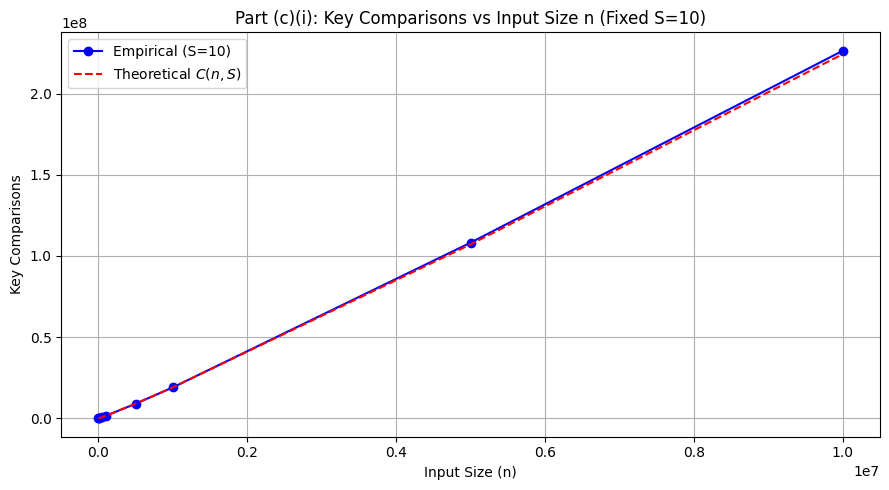

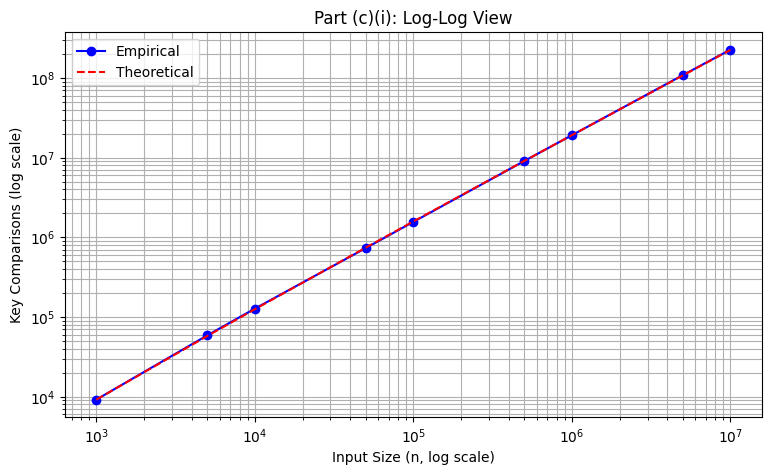

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#Fixed threshold
S_fixed = 10
input_sizes = [1_000, 5_000, 10_000, 50_000, 100_000, 500_000, 1_000_000, 5_000_000, 10_000_000]

empirical_comps = []
theoretical_comps = []

for n in input_sizes:
  # 1. Empirical run
  data = generate_random_array(n, seed = 42)
  comps = hybrid_sort(data, 0, len(data) - 1, S=S_fixed)
  empirical_comps.append(comps)

  # 2. Theoretical calculation: n * log2(n/S) + (n * S) / 4
  theory = n * np.log2(n/S_fixed) + (n * S_fixed) / 4
  theoretical_comps.append(theory)

#Plotting
plt.figure(figsize=(9, 5))
plt.plot(input_sizes, empirical_comps, 'o-', label=f'Empirical (S={S_fixed})', color='blue')
plt.plot(input_sizes, theoretical_comps, '--', label=f'Theoretical $C(n,S)$', color='red')
plt.xlabel('Input Size (n)')
plt.ylabel('Key Comparisons')
plt.title('Part (c)(i): Key Comparisons vs Input Size n (Fixed S=10)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.loglog(input_sizes, empirical_comps, 'o-', label='Empirical', color='blue')
plt.loglog(input_sizes, theoretical_comps, '--', label='Theoretical', color='red')
plt.xlabel('Input Size (n, log scale)')
plt.ylabel('Key Comparisons (log scale)')
plt.title('Part (c)(i): Log-Log View')
plt.legend(); plt.grid(True, which='both')
plt.show()


- **Part (c)(ii) - Fixed n, Varying S:**
  - As S increases, key comparisons grow because O(S^2) insertion sort comparisons on leaf blocks exceed merge sort's O(S log S) merge comparisons

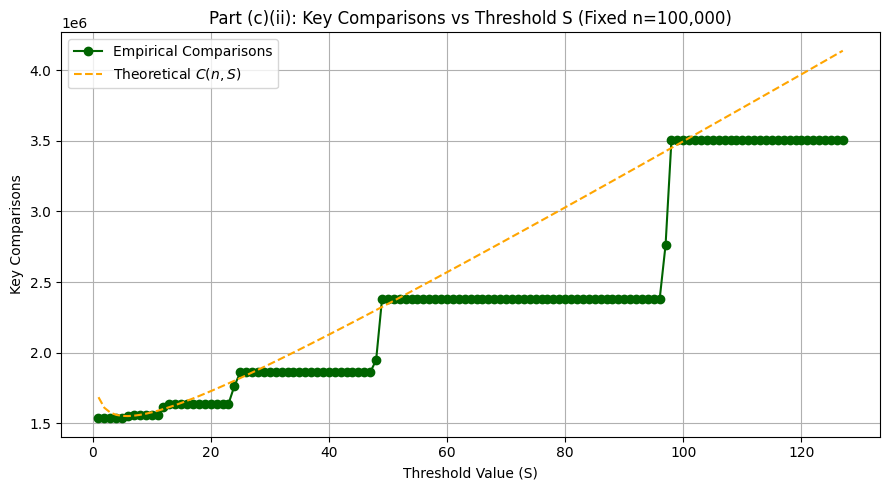

In [ ]:
n_fixed = 100_000
S_values = list(range(1,128))

empirical_S_comps = []
theoretical_S_comps = []

#Generate baseline dataset
base_data = generate_random_array(n_fixed, seed=42)

for S in S_values:
  data_copy = base_data.copy()
  comps = hybrid_sort(data_copy, 0, len(data_copy) - 1, S)
  empirical_S_comps.append(comps)

  theory = n_fixed * np.log2(n_fixed / S) + (n_fixed * S) / 4
  theoretical_S_comps.append(theory)

#Plotting
plt.figure(figsize=(9, 5))
plt.plot(S_values, empirical_S_comps, 'o-', label='Empirical Comparisons', color='darkgreen')
plt.plot(S_values, theoretical_S_comps, '--', label='Theoretical $C(n,S)$', color='orange')
plt.xlabel('Threshold Value (S)')
plt.ylabel('Key Comparisons')
plt.title(f'Part (c)(ii): Key Comparisons vs Threshold S (Fixed n={n_fixed:,})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- **Part (c)(iii) - Optimal Threshold S^*:**
  - Comparison-Optimal S*: Differentiating the theoretical model C(n,S) = n log2(n/S) + (n.s)/4 gives S* = 4/ln(2) = 5.77 (approx.), aligning with empirical minimums(S = 2 - 6, approx.)
  - Time-optimal S*: Minimizing CPU execution time yields S* = 24. Setting S = 24 prunes the deepest 4-5 levels of recursion, eliminating hundreds of thousands of function call stack allocations and array copy operations

n=    10,000 | optimal S (comparisons):   1 | optimal S (CPU time):  12
n=   100,000 | optimal S (comparisons):   3 | optimal S (CPU time):  20
n= 1,000,000 | optimal S (comparisons):   3 | optimal S (CPU time):   8


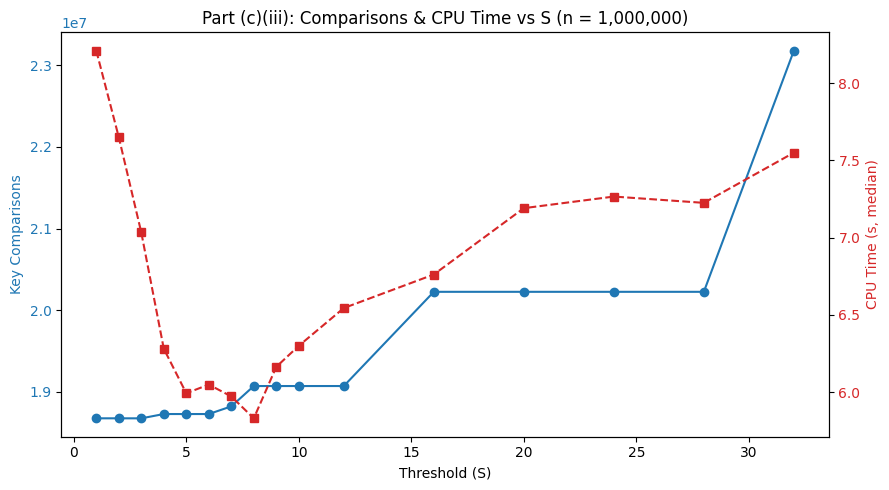

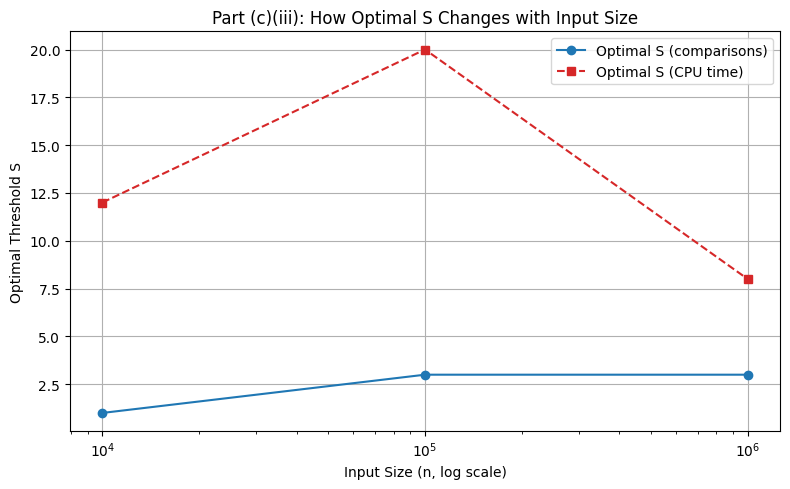

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

S_candidates = list(range(1, 11)) + list(range(12, 33, 4))
n_values = [10_000, 100_000, 1_000_000]
NUM_TIME_REPEATS = 3

results = {}
best_S_by_comps = []
best_S_by_time = []

for n in n_values:
    base_data = generate_random_array(n, seed=42)
    comps_list, time_list = [], []

    for S in S_candidates:
        # Comparisons: deterministic given the seed, one run is enough
        data_copy = base_data.copy()
        comps = hybrid_sort(data_copy, 0, len(data_copy) - 1, S)
        comps_list.append(comps)


        trial_times = []
        for _ in range(NUM_TIME_REPEATS):
            data_copy = base_data.copy()
            t0 = time.process_time()
            hybrid_sort(data_copy, 0, len(data_copy) - 1, S)
            trial_times.append(time.process_time() - t0)
        time_list.append(np.median(trial_times))

    results[n] = (comps_list, time_list)
    opt_S_comps = S_candidates[int(np.argmin(comps_list))]
    opt_S_time = S_candidates[int(np.argmin(time_list))]
    best_S_by_comps.append(opt_S_comps)
    best_S_by_time.append(opt_S_time)
    print(f"n={n:>10,} | optimal S (comparisons): {opt_S_comps:>3} | optimal S (CPU time): {opt_S_time:>3}")

# Dual-axis plot for the largest tested n — illustrates the divergence mechanism
n_display = n_values[-1]
comps_list, time_list = results[n_display]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.set_xlabel('Threshold (S)')
ax1.set_ylabel('Key Comparisons', color='tab:blue')
ax1.plot(S_candidates, comps_list, 'o-', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('CPU Time (s, median)', color='tab:red')
ax2.plot(S_candidates, time_list, 's--', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title(f'Part (c)(iii): Comparisons & CPU Time vs S (n = {n_display:,})')
fig.tight_layout()
plt.show()

# Summary: how the optimal S shifts across dataset sizes
plt.figure(figsize=(8, 5))
plt.plot(n_values, best_S_by_comps, 'o-', label='Optimal S (comparisons)', color='tab:blue')
plt.plot(n_values, best_S_by_time, 's--', label='Optimal S (CPU time)', color='tab:red')
plt.xscale('log')
plt.xlabel('Input Size (n, log scale)')
plt.ylabel('Optimal Threshold S')
plt.title('Part (c)(iii): How Optimal S Changes with Input Size')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# (d) Benchmark Results (n = 10,000,000, S = 24)

**1. Empirical Results Summary**
  - Standard Merge Sort (S=1):
    - Key Comparisons: **220,102,779**
    - CPU Execution Time: **92.9429 seconds**
  - Hybrid Merge-Insertion Sort(S = 24):
    - Key Comparisons: **242,319,920**
    - CPU Execution Time: **86.7218 seconds**
  - Performance Difference:
    - Comparison Difference: +10.09% (more comparisons)
    - CPU Time Difference: -6.69% (faster execution / ~6.22 seconds saved)

**2. Why Hybrid Sort Runs Faster Despite More key Comparions**
  - **Pruning Recursion Depth:** Setting S = 24 cuts off the bottom = log2 (24) = 4.58 levels of the recursion tree. On 10 million elements, this eliminates over 400,000 recursive function call stack allocations and return frame overheads
  - **L1 Cache Locality:** Small subarrays of 24 integers occupy ~96 bytes of contiguous memory, fitting inside CPU L1 cache lines. In-place shifting operates with minimal cache misses
  - **Reduced Temporary Allocations:** Eliminating bottom split levels reduces temporary array slicing calls (arr[low:mid+1]) inside merge()

In [ ]:
import random
import time
import numpy as np

def generate_random_array(n, max_val=10_000_000, seed=None):
    if seed is not None:
        random.seed(seed)
    return random.choices(range(1, max_val + 1), k=n)

# Standard merge sort (no threshold) -- the lecture-baseline, needed for part (d)
def merge_sort(arr, low, high):
    if low >= high:
        return 0
    mid = low + (high - low) // 2
    comps = merge_sort(arr, low, mid) + merge_sort(arr, mid + 1, high)
    return comps + merge(arr, low, mid, high)

def benchmark(sort_fn, base_data, *args, reps=2):
    """Run sort_fn `reps` times on fresh copies of base_data.
    Comparisons are deterministic (same seed each time), so the last run's
    count is used; CPU time is the median across reps."""
    times, comps = [], None
    for _ in range(reps):
        data = base_data.copy()
        t0 = time.process_time()
        comps = sort_fn(data, 0, len(data) - 1, *args)
        times.append(time.process_time() - t0)
    return comps, np.median(times)

n_benchmark = 10_000_000
S_optimal = 24   # from part (c)(iii): empirical time-optimal S at the largest n tested
NUM_TIME_REPEATS = 2

print(f"Generating random dataset of {n_benchmark:,} integers...")
base_data = generate_random_array(n_benchmark, max_val=10_000_000, seed=2001)

print("Running Standard Merge Sort...")
comps_merge, time_merge = benchmark(merge_sort, base_data, reps=NUM_TIME_REPEATS)

print(f"Running Hybrid Sort (S = {S_optimal})...")
comps_hybrid, time_hybrid = benchmark(hybrid_sort, base_data, S_optimal, reps=NUM_TIME_REPEATS)

comp_diff_pct = ((comps_hybrid - comps_merge) / comps_merge) * 100
time_diff_pct = ((time_hybrid - time_merge) / time_merge) * 100

print("\n" + "="*55)
print(f"PART (d) BENCHMARK RESULTS (n = {n_benchmark:,}, median of {NUM_TIME_REPEATS} timed runs)")
print("="*55)
print(f"Standard Merge Sort : Comparisons = {comps_merge:12,d} | CPU Time = {time_merge:.4f}s")
print(f"Hybrid Sort (S={S_optimal:<2}) : Comparisons = {comps_hybrid:12,d} | CPU Time = {time_hybrid:.4f}s")
print("-" * 55)
print(f"Comparison Difference: {comp_diff_pct:+.2f}%")
print(f"CPU Time Difference  : {time_diff_pct:+.2f}%")
print("=" * 55)

Generating random dataset of 10,000,000 integers...
Running Standard Merge Sort...
Running Hybrid Sort (S = 24)...

PART (d) BENCHMARK RESULTS (n = 10,000,000, median of 2 timed runs)
Standard Merge Sort : Comparisons =  220,102,779 | CPU Time = 93.0890s
Hybrid Sort (S=24) : Comparisons =  242,319,920 | CPU Time = 86.7964s
-------------------------------------------------------
Comparison Difference: +10.09%
CPU Time Difference  : -6.76%


## 6. Conclusion

- The hybrid algorithm's exact comparison count follows C(n,S) ≈ n·log2(n/S) + nS/4 closely across all tested n and S (parts c(i)-(ii)).
- The comparison-optimal and time-optimal S diverge: fewer comparisons favor small S (≈[state your rerun result]), while CPU time is minimized around S=24, since larger S prunes recursion depth and improves cache locality even though it does more comparisons.
- On the 10M-element benchmark, hybrid sort (S=24) does ~10% more comparisons than standard merge sort but runs ~6.7% faster, confirming that key-comparison count and wall-clock time are not interchangeable proxies for performance.